In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Reading the Evaluation data by Pathologist

In [2]:
eval_data = pd.read_csv('data/pathopen_image_augmentation_eval_data.csv')
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,Evaluation Image_Augmentation\n(Benchmark 4),Unnamed: 6,OE_Question_2,OE_Correct_Answer_2,Evaluation Image_Augmentation\n(Benchmark 4).1,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,Clinical Relevance,Visual Grounding,NaN,NaN,Clinical Relevance,Visual Grounding
1,148.0,img_pathopen_148_01_aug_0.png,https://drive.google.com/file/d/1iwqNhkvNBL4iI...,What are the main inflammatory cell types seen...,The biopsy shows a cellular lesion comprised o...,2,2,What is the most likely diagnosis suggested by...,The lesion shows large atypical mononuclear ce...,2,2
2,142.0,img_pathopen_142_03_aug_2.png,https://drive.google.com/file/d/1en7HkPZzhxKnb...,Based on the image depicting a section of the ...,The image shows typical changes of Graves dise...,2,2,What is the best histologic description of thi...,The image shows typical changes of Grave's dis...,2,2
3,117.0,img_pathopen_117_01_aug_1.png,https://drive.google.com/file/d/1yiLkYnwp4-e4e...,What is the classic description of the tumor d...,The image depicts a wilms tumor showing classi...,2,2,In this image depicting a sample from a kidney...,"This is a wilms tumor and the blastema, primit...",2,2
4,129.0,img_pathopen_129_02_aug_1.png,https://drive.google.com/file/d/1oi6xVKJa5xHxb...,What is the general category of lesion and are...,The lesion generically shows a fibroepithelial...,1,2,What are the histologic findings in this image...,This fibroepithelial lesion is likely not to r...,0,0


Renaming some columns

In [3]:
eval_data = eval_data.rename(columns={'Evaluation Image_Augmentation\n(Benchmark 4)': 'OE_Image_Augmentation_1_Clin_Relv',
                                        'Unnamed: 6': 'OE_Image_Augmentation_1_Vis_Ground',
                                        'Evaluation Image_Augmentation\n(Benchmark 4).1': 'OE_Image_Augmentation_2_Clin_Relv',
                                        'Unnamed: 10': 'OE_Image_Augmentation_2_Vis_Ground',
                                        })

eval_data = eval_data.drop(index=0) #dropping the first row which contains the benchmark names
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,OE_Image_Augmentation_1_Clin_Relv,OE_Image_Augmentation_1_Vis_Ground,OE_Question_2,OE_Correct_Answer_2,OE_Image_Augmentation_2_Clin_Relv,OE_Image_Augmentation_2_Vis_Ground
1,148.0,img_pathopen_148_01_aug_0.png,https://drive.google.com/file/d/1iwqNhkvNBL4iI...,What are the main inflammatory cell types seen...,The biopsy shows a cellular lesion comprised o...,2,2,What is the most likely diagnosis suggested by...,The lesion shows large atypical mononuclear ce...,2,2
2,142.0,img_pathopen_142_03_aug_2.png,https://drive.google.com/file/d/1en7HkPZzhxKnb...,Based on the image depicting a section of the ...,The image shows typical changes of Graves dise...,2,2,What is the best histologic description of thi...,The image shows typical changes of Grave's dis...,2,2
3,117.0,img_pathopen_117_01_aug_1.png,https://drive.google.com/file/d/1yiLkYnwp4-e4e...,What is the classic description of the tumor d...,The image depicts a wilms tumor showing classi...,2,2,In this image depicting a sample from a kidney...,"This is a wilms tumor and the blastema, primit...",2,2
4,129.0,img_pathopen_129_02_aug_1.png,https://drive.google.com/file/d/1oi6xVKJa5xHxb...,What is the general category of lesion and are...,The lesion generically shows a fibroepithelial...,1,2,What are the histologic findings in this image...,This fibroepithelial lesion is likely not to r...,0,0
5,137.0,img_pathopen_137_03_aug_0.png,https://drive.google.com/file/d/1mbMRpC_Bywi_f...,What is the abnormality observed in this image...,The image depicts a molar pregnancy with unifo...,2,2,What is the expected chromosomal findings pred...,The image depicts likely complete hydatidiform...,2,2


Converting all the evaluation columns from Str to Int

In [4]:
eval_data = eval_data.astype({'OE_Image_Augmentation_1_Clin_Relv': 'float',
                                'OE_Image_Augmentation_1_Vis_Ground': 'float',
                                'OE_Image_Augmentation_2_Clin_Relv': 'float',
                                'OE_Image_Augmentation_2_Vis_Ground': 'float',
                                })

eval_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 1 to 34
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   CASE_ID                             34 non-null     float64
 1   Image_ID                            34 non-null     str    
 2   Image_URL                           34 non-null     str    
 3   OE_Question_1                       34 non-null     str    
 4   OE_Correct_Answer_1                 34 non-null     str    
 5   OE_Image_Augmentation_1_Clin_Relv   34 non-null     float64
 6   OE_Image_Augmentation_1_Vis_Ground  34 non-null     float64
 7   OE_Question_2                       32 non-null     str    
 8   OE_Correct_Answer_2                 32 non-null     str    
 9   OE_Image_Augmentation_2_Clin_Relv   32 non-null     float64
 10  OE_Image_Augmentation_2_Vis_Ground  32 non-null     float64
dtypes: float64(5), str(6)
memory usage: 3.1 KB


Finding Missing Evaluations or Wrong Evaluations

In [5]:
OE_Correct_Answer_1_Clin_Relv_Missing = eval_data[(eval_data['OE_Question_1'].notnull()) & (eval_data['OE_Correct_Answer_1'].notnull()) & ((eval_data['OE_Image_Augmentation_1_Clin_Relv'].isnull()) | (~eval_data['OE_Image_Augmentation_1_Clin_Relv'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_1_Vis_Ground_Missing = eval_data[(eval_data['OE_Question_1'].notnull()) & (eval_data['OE_Correct_Answer_1'].notnull()) & ((eval_data['OE_Image_Augmentation_1_Vis_Ground'].isnull()) | (~eval_data['OE_Image_Augmentation_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Clin_Relv_Missing = eval_data[(eval_data['OE_Question_2'].notnull()) & (eval_data['OE_Correct_Answer_2'].notnull()) & ((eval_data['OE_Image_Augmentation_2_Clin_Relv'].isnull()) | (~eval_data['OE_Image_Augmentation_2_Clin_Relv'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Vis_Ground_Missing = eval_data[(eval_data['OE_Question_2'].notnull()) & (eval_data['OE_Correct_Answer_2'].notnull()) & ((eval_data['OE_Image_Augmentation_2_Vis_Ground'].isnull()) | (~eval_data['OE_Image_Augmentation_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()

print(f"OE_Correct_Answer_1_Clin_Relv_Missing: {OE_Correct_Answer_1_Clin_Relv_Missing}")
print(f"OE_Correct_Answer_1_Vis_Ground_Missing: {OE_Correct_Answer_1_Vis_Ground_Missing}")
print(f"OE_Correct_Answer_2_Clin_Relv_Missing: {OE_Correct_Answer_2_Clin_Relv_Missing}")
print(f"OE_Correct_Answer_2_Vis_Ground_Missing: {OE_Correct_Answer_2_Vis_Ground_Missing}")

OE_Correct_Answer_1_Clin_Relv_Missing: []
OE_Correct_Answer_1_Vis_Ground_Missing: []
OE_Correct_Answer_2_Clin_Relv_Missing: []
OE_Correct_Answer_2_Vis_Ground_Missing: []


#### Correct Answer

1

In [6]:
oe_correct_answer_1_clin_relv_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Image_Augmentation_1_Clin_Relv'].notnull()]
oe_correct_answer_1_clin_relv_total = len(oe_correct_answer_1_clin_relv_df)
oe_correct_answer_1_clin_relv_eval_2 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == 2])
oe_correct_answer_1_clin_relv_eval_1 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == 1])
oe_correct_answer_1_clin_relv_eval_0 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == 0])
oe_correct_answer_1_clin_relv_eval_neg_1 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == -1])

In [7]:
oe_correct_answer_1_vis_ground_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Image_Augmentation_1_Vis_Ground'].notnull()]
oe_correct_answer_1_vis_ground_total = len(oe_correct_answer_1_vis_ground_df)
oe_correct_answer_1_vis_ground_eval_2 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == 2])
oe_correct_answer_1_vis_ground_eval_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == 1])
oe_correct_answer_1_vis_ground_eval_0 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == 0])
oe_correct_answer_1_vis_ground_eval_neg_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == -1])


2

In [8]:
oe_correct_answer_2_clin_relv_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Image_Augmentation_2_Clin_Relv'].notnull()]
oe_correct_answer_2_clin_relv_total = len(oe_correct_answer_2_clin_relv_df)
oe_correct_answer_2_clin_relv_eval_2 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == 2])
oe_correct_answer_2_clin_relv_eval_1 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == 1])
oe_correct_answer_2_clin_relv_eval_0 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == 0])
oe_correct_answer_2_clin_relv_eval_neg_1 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == -1])

In [10]:
oe_correct_answer_2_vis_ground_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Image_Augmentation_2_Vis_Ground'].notnull()]
oe_correct_answer_2_vis_ground_total = len(oe_correct_answer_2_vis_ground_df)
oe_correct_answer_2_vis_ground_eval_2 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == 2])
oe_correct_answer_2_vis_ground_eval_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == 1])
oe_correct_answer_2_vis_ground_eval_0 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == 0])
oe_correct_answer_2_vis_ground_eval_neg_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == -1])

Calculating the consolidated information all the correct questions/answers

In [11]:
correct_answer_benchmark_label = [
                                    'Clinical Relevance',
                                    'Visual Grounding',
                                ]

correct_answer_total = [oe_correct_answer_1_clin_relv_total + oe_correct_answer_2_clin_relv_total,
                        oe_correct_answer_1_vis_ground_total + oe_correct_answer_2_vis_ground_total
                        ]

correct_answer_eval_2 = [oe_correct_answer_1_clin_relv_eval_2 + oe_correct_answer_2_clin_relv_eval_2,
                        oe_correct_answer_1_vis_ground_eval_2 + oe_correct_answer_2_vis_ground_eval_2,
                        ]

correct_answer_eval_1 = [oe_correct_answer_1_clin_relv_eval_1 + oe_correct_answer_2_clin_relv_eval_1,
                        oe_correct_answer_1_vis_ground_eval_1 + oe_correct_answer_2_vis_ground_eval_1,
                        ]

correct_answer_eval_0 = [oe_correct_answer_1_clin_relv_eval_0 + oe_correct_answer_2_clin_relv_eval_0,
                        oe_correct_answer_1_vis_ground_eval_0 + oe_correct_answer_2_vis_ground_eval_0
                        ]

correct_answer_eval_neg_1 = [oe_correct_answer_1_clin_relv_eval_neg_1 + oe_correct_answer_2_clin_relv_eval_neg_1,
                            oe_correct_answer_1_vis_ground_eval_neg_1 + oe_correct_answer_2_vis_ground_eval_neg_1
                            ]

correct_answer_eval_data = pd.DataFrame({'Score: 2': correct_answer_eval_2,
                                        'Score: 1': correct_answer_eval_1,
                                        'Score: 0': correct_answer_eval_0,
                                        'Score: -1': correct_answer_eval_neg_1}, index=[correct_answer_benchmark_label])

correct_answer_eval_data

,Score: 2,Score: 1,Score: 0,Score: -1
Clinical Relevance,62,3,1,0
Visual Grounding,64,1,1,0


Open-Ended Image Augmentation Graph

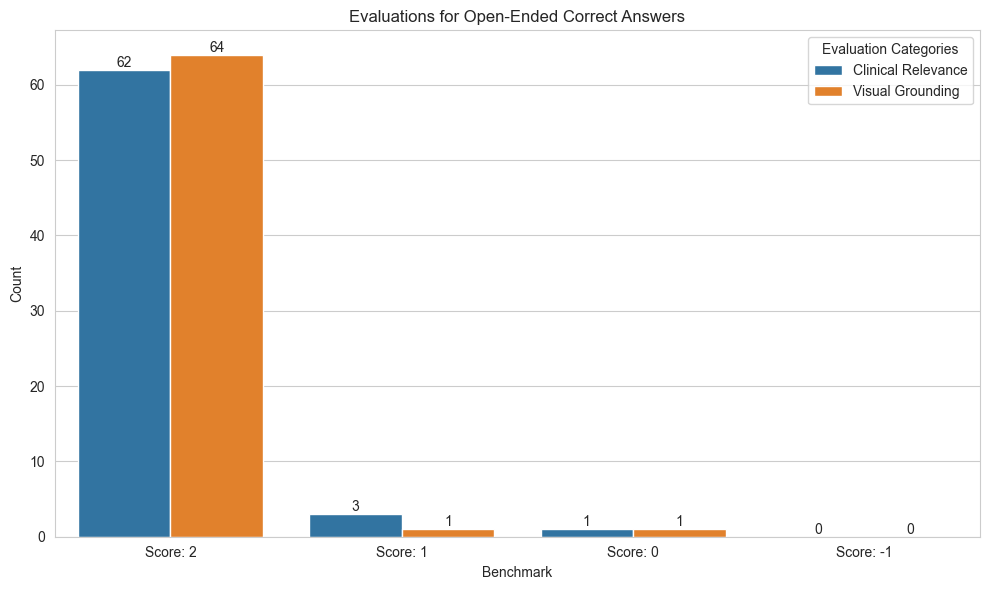

In [21]:
temp_data = correct_answer_eval_data.reset_index().melt(id_vars='level_0', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='level_0')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Evaluations for Open-Ended Correct Answers')
plt.xlabel('Benchmark')
plt.ylabel('Count')
plt.legend(title='Evaluation Categories')
plt.tight_layout()
plt.show()